In [1]:
import pandas as pd, glob, os

# re-use DATASET_DIR and columns from previous notebook if running in same kernel
try:
    DATASET_DIR, columns
except NameError:
    CANDIDATES = ["datasets", "../datasets", "../../datasets"]
    for c in CANDIDATES:
        if os.path.isfile(os.path.join(c, "data_names.csv")):
            DATASET_DIR = c
            break
    columns = pd.read_csv(os.path.join(DATASET_DIR, "data_names.csv"), header=None).iloc[0].tolist()

files = sorted(glob.glob(os.path.join(DATASET_DIR, "data_*.csv")))
parts = []
for f in files[:5]:               # first 5 parts
    part = pd.read_csv(f, names=columns, nrows=50_000, low_memory=False)  # 50k rows each
    parts.append(part)

df = pd.concat(parts, ignore_index=True)
print("sample shape:", df.shape)
df.head()


sample shape: (250000, 35)


,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
1,1,1526344121.188091,e,arp,192.168.100.1,NaN,192.168.100.3,NaN,4,240,...,2,2,120,120,0.002508,0.000836,0.000836,0,Normal,Normal
2,2,1526344223.197482,e,tcp,192.168.100.7,139,192.168.100.4,36390,10,680,...,5,5,350,330,0.00619,0.002751,0.002751,0,Normal,Normal
3,3,1526344227.029374,e,udp,192.168.100.149,51838,27.124.125.250,123,2,180,...,1,1,90,90,20.59096,0.0,0.0,0,Normal,Normal
4,4,1526344228.312317,e,arp,192.168.100.4,NaN,192.168.100.7,NaN,10,510,...,5,5,210,300,0.006189,0.002751,0.002751,0,Normal,Normal


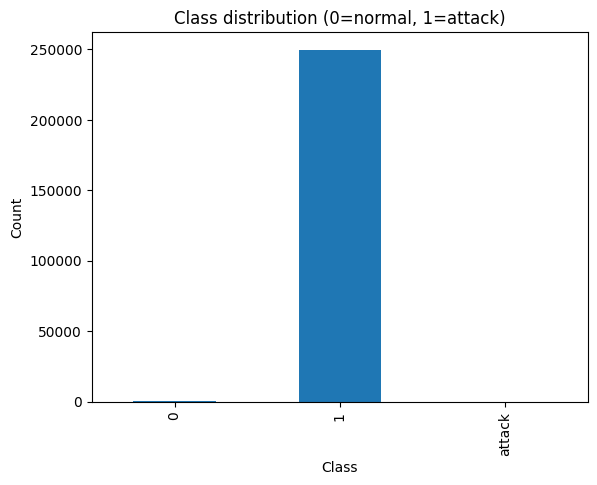

attack
0            255
1         249740
attack         5
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt

LABEL = "label" if "label" in df.columns else ("attack" if "attack" in df.columns else None)
assert LABEL is not None, "Label column not found in sample."

counts = df[LABEL].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("Class distribution (0=normal, 1=attack)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

counts


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.values, test_size=0.3, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


NameError: name 'X_scaled' is not defined

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

DROP_COLS = ["src_ip","dst_ip","sport","dport","state","timestamp","flow_id"]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

y = df[LABEL].astype(int)
X = df.drop(DROP_COLS + [LABEL], axis=1, errors="ignore").copy()

# one-hot for categoricals (e.g., proto/state if object)
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# clean & scale
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.shape, len(cat_cols)
